# Caso Vértice · Da estratégia ao chão do CD, com dados

**Vértice Commerce & Logística** é uma empresa **fictícia** de grande porte, com operação híbrida (própria + 3PL), que em 2025 saiu do Sul/Sudeste para o Brasil inteiro. Este notebook percorre o ciclo completo:

1. **Linha de base × mercado**: onde estamos em relação ao Mercado Livre (divulgação 2T26) e ao WERC 2025
2. **Diagnóstico da cadeia**: como o pico de fim de ano se propaga do CD ao cliente
3. **CEP**: separar ruído de sinal (e o erro da carta p com n gigante)
4. **Capability**: o SLA de dock-to-stock é sustentável?
5. **Capacidade**: equilibrar pessoas, horas extras, temporários e 3PL sem sacrificar custo nem o plano de 2027
6. **OKRs 2026**: nota calculada direto dos dados, com contrapeso

> Dados sintéticos gerados por `kpikit.simulador` (causal, com semente fixa). Benchmarks reais e fontes em `00-fundamentos/linha-de-base-mercado.md`.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from kpikit import simulador, kpis, spc, capacidade, okr, config
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
d = simulador.carregar()
{k: len(v) for k, v in d.items()}

{'dim_calendario': 638,
 'dim_regiao': 5,
 'dim_unidade': 24,
 'fato_cd': 4466,
 'fato_demanda': 3190,
 'fato_hub': 3190,
 'fato_last_mile': 6660,
 'fato_linehaul': 3190,
 'fato_midia': 3190,
 'fato_pessoas': 132}

## 1. Linha de base (2º semestre de 2025) × meta 2026 × benchmark

In [2]:
painel = kpis.painel_metas(d)
painel[['kpi_id','kpi','linha_base','meta_2026','benchmark','confianca','fonte_benchmark']]

,kpi_id,kpi,linha_base,meta_2026,benchmark,confianca,fonte_benchmark
0,LM-011,Pedidos entregues em até 48h,0.6501,0.8000,0.7700,A,Mercado Livre 2T26 — envios rápidos em até 48h
1,SC-009,Expedição no cut-off,0.9620,0.9900,0.9950,B,WERC DC Measures 2025 — best-in-class on-time ...
2,SC-007,Acurácia de picking,0.9964,0.9968,0.9968,B,WERC DC Measures 2025 — best-in-class
3,SC-006,Dock-to-stock P90,7.3433,4.0000,3.5000,B,WERC DC Measures 2025 — best-in-class
4,LM-002,FADR,0.9026,0.9300,0.9000,C,Fornecedores de roteirização (faixa 'forte' > ...
5,LM-001,OTD vs. promessa,0.8949,0.9600,NaN,D,
6,LM-003,Custo por entrega,14.4362,12.5000,NaN,D,
7,MK-002,POAS,1.5379,1.8000,NaN,D,
8,PE-003,Turnover precoce (<90d),0.3220,0.2000,NaN,D,


**Leitura.** Em 48h, a Vértice (65%) está 12 p.p. atrás da régua pública do Mercado Livre (77% dos envios rápidos em até 48h no 2T26). Os denominadores, porém, não são idênticos: o MELI reporta *envios rápidos*, não o total de pedidos. Na acurácia de picking a distância para o best-in-class do WERC é pequena; no dock-to-stock é grande (7,3 h contra < 3,5 h).

## 2. O pico se propaga pela cadeia

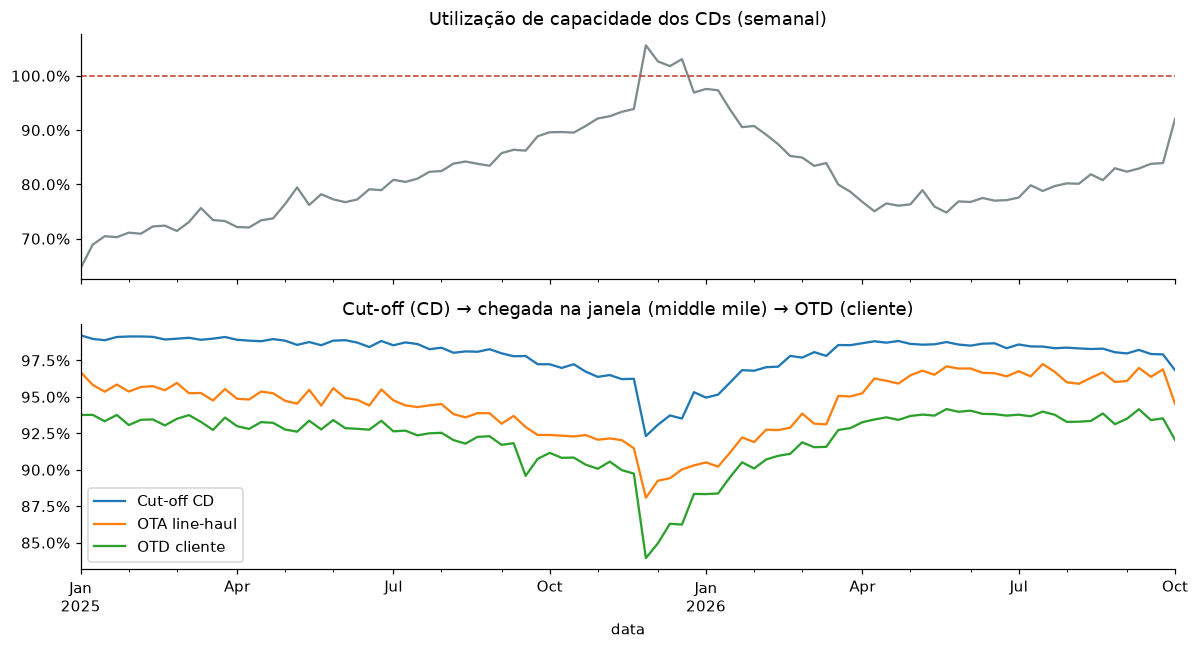

In [3]:
serie = pd.concat([kpis.calcular(d, k, freq='W') for k in ['SC-012','SC-009','MM-002','LM-001']], axis=1)
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
serie['SC-012'].plot(ax=ax[0], color='#7f8c8d', title='Utilização de capacidade dos CDs (semanal)')
ax[0].axhline(1, color='#c0392b', ls='--', lw=1); ax[0].yaxis.set_major_formatter(PercentFormatter(1))
serie[['SC-009','MM-002','LM-001']].plot(ax=ax[1], title='Cut-off (CD) → chegada na janela (middle mile) → OTD (cliente)')
ax[1].yaxis.set_major_formatter(PercentFormatter(1)); ax[1].legend(['Cut-off CD','OTA line-haul','OTD cliente'])
plt.tight_layout()

In [4]:
bf = ('2025-11-24', '2025-12-01')
pd.DataFrame({k: [kpis.calcular(d, k, inicio='2025-10-01', fim='2025-10-31'), kpis.calcular(d, k, inicio=bf[0], fim=bf[1])]
              for k in ['SC-012','SC-009','SC-007','MM-002','LM-001','LM-002','LM-007']},
             index=['Outubro/25', 'Black Friday/25']).T

,Outubro/25,Black Friday/25
SC-012,0.9055,1.0838
SC-009,0.9691,0.9137
SC-007,0.9968,0.9951
MM-002,0.9232,0.8738
LM-001,0.9065,0.8251
LM-002,0.9078,0.8740
LM-007,4.4820,7.3472


**Leitura.** Quando a utilização dos CDs passa de ~90%, o cut-off cai de forma **não linear**, e cada elo seguinte herda e amplifica a perda: o OTD ao cliente cai mais que o cut-off. Contatos no SAC sobem junto. É o custo invisível do pico mal dimensionado, que volta para o marketing como CAC mais alto.

## 3. CEP · ruído ou sinal?

['20/07/2025',
 '03/08/2025',
 '16/09/2025',
 '17/09/2025',
 '18/09/2025',
 '17/11/2025',
 '18/11/2025',
 '24/11/2025',
 '25/11/2025',
 '01/12/2025',
 '08/12/2025',
 '10/12/2025',
 '15/12/2025',
 '16/12/2025',
 '22/12/2025',
 '30/12/2025',
 '05/01/2026']

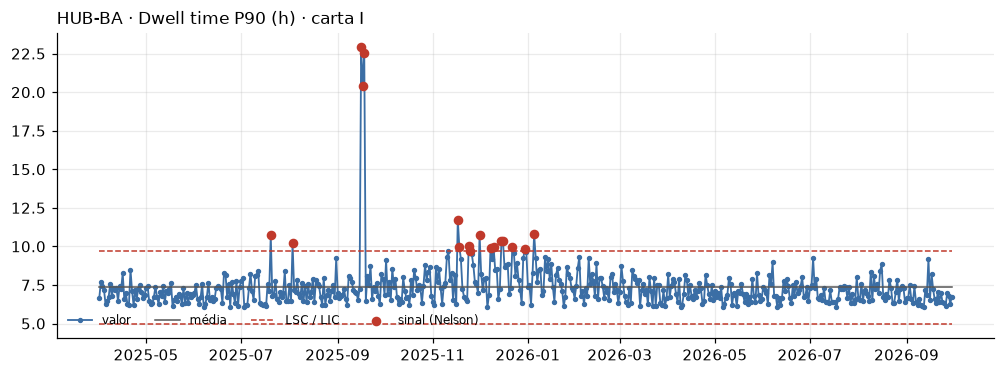

In [5]:
hub = d['fato_hub'].query("unidade_id == 'HUB-BA'").set_index('data').dwell_time_p90_h.dropna()
carta = spc.carta_imr(hub); sinais = spc.regras_nelson(carta)
spc.plotar(carta, 'HUB-BA · Dwell time P90 (h) · carta I', sinais.regra_1)
carta[sinais.regra_1].index.strftime('%d/%m/%Y').tolist()

A carta I detecta a **pane do sorter (16–18/09/2025)** injetada na simulação e os picos de fim de ano. Nos dias restantes, a variação é ruído comum. Reagir a ela (*tampering*) só aumenta a variação.

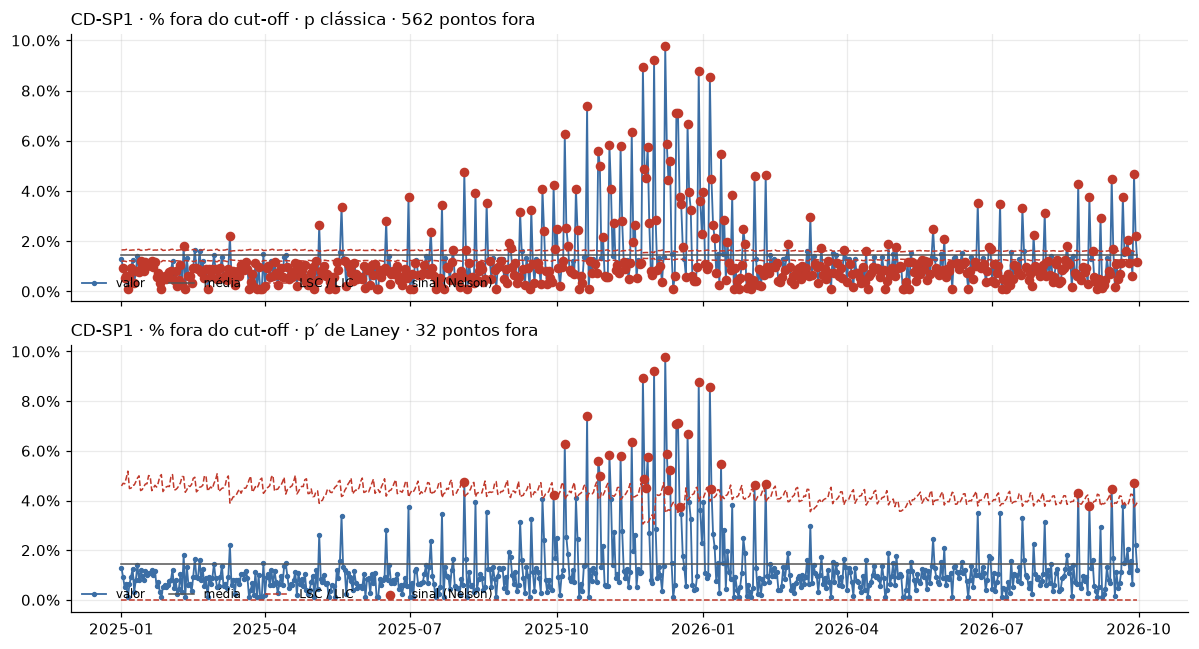

In [6]:
cd = d['fato_cd'].query("unidade_id == 'CD-SP1'").set_index('data')
nc = cd.pedidos - cd.pedidos_expedidos_cutoff
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for a, laney in zip(ax, [False, True]):
    c = spc.carta_p(nc, cd.pedidos, laney=laney); s = spc.regras_nelson(c)
    spc.plotar(c, f"CD-SP1 · % fora do cut-off · {'p′ de Laney' if laney else 'p clássica'} · {s.regra_1.sum()} pontos fora", s.regra_1, ax=a, formato_pct=True)
plt.tight_layout()

**Erro clássico em logística.** Com ~40 mil pedidos por dia, a carta p clássica tem limites tão estreitos que **quase todos os dias** parecem causa especial. É sobredispersão: a variação real entre dias é muito maior que a binomial. A carta **p′ de Laney** mede essa variação e devolve à carta seu poder de decisão.

## 4. Capability · o SLA de dock-to-stock de 12 h é sustentável?

In [7]:
pd.DataFrame({u: spc.capabilidade(d['fato_cd'].query('unidade_id == @u and pedidos > 0').dock_to_stock_p90_h, lse=12)
              for u in sorted(d['fato_cd'].unidade_id.unique())}).T[['media','Cpk','Ppk','pct_fora_spec_observado']]

,media,Cpk,Ppk,pct_fora_spec_observado
CD-AM1,8.9929,0.7669,0.5225,0.0610
CD-GO1,7.7781,1.4226,0.9504,0.0164
CD-PE1,6.0232,1.8912,0.9018,0.0036
CD-PR1,5.5309,1.9805,1.3197,0.0016
CD-RJ1,5.2813,2.5047,1.5762,0.0000
CD-SP1,5.2233,2.7092,1.6410,0.0000
CD-SP2,7.1620,1.7814,1.5754,0.0016


Os CDs das regiões em expansão (AM1, GO1, PE1) têm Ppk muito abaixo do Cpk: o processo **ainda não é estável** (curva de aprendizagem + pico). O CD-AM1 não é capaz nem no curto prazo (Cpk < 1). Nesses casos o índice de capability não vale como promessa contratual. A ordem é **controlar, depois medir capability, depois contratar SLA**.

In [8]:
erros, linhas = d['fato_cd'].linhas_com_erro.sum(), d['fato_cd'].linhas_separadas.sum()
dp = spc.dpmo(erros, linhas); print(f'Picking: {dp:,.0f} DPMO → {spc.nivel_sigma(dp):.2f}σ (convenção com deslocamento de 1,5σ)')

Picking: 3,064 DPMO → 4.24σ (convenção com deslocamento de 1,5σ)


## 5. Capacidade · equilibrar pessoas e recursos sem sacrificar custo nem o futuro

Programação linear semanal para o 4T26 (demanda = 4T25 × 1,35). Decide quadro próprio, contratações, horas extras, temporários e 3PL, minimizando custo com restrições de **SLA** (buffer), **qualidade** (acurácia ponderada do mix), **saúde e legislação** (limite de HE), **risco** (dependência de 3PL) e **futuro** (quadro mínimo ao final).

In [9]:
cen = capacidade.Cenario(demanda=capacidade.demanda_projetada(d))
r = capacidade.otimizar(cen)
print(f'Custo total R$ {r.custo_total/1e6:,.1f} mi · R$ {r.custo_por_pedido:.2f}/pedido · acurácia do mix {r.acuracia_mix:.3%} · 3PL {r.participacao_3pl:.1%}')
r.plano[['demanda','quadro_proprio','contratacoes','horas_extras','horas_temporarios','pedidos_3pl','acuracia_mix']].round(0)

Custo total R$ 161.5 mi · R$ 6.83/pedido · acurácia do mix 99.740% · 3PL 4.2%


,demanda,quadro_proprio,contratacoes,horas_extras,horas_temporarios,pedidos_3pl,acuracia_mix
semana,,,,,,,
2026-09-14,"1,153,933.0000","3,785.0000",500.0000,0.0000,0.0000,"87,694.0000",1.0000
2026-09-21,"1,155,306.0000","3,926.0000",141.0000,0.0000,0.0000,0.0000,1.0000
2026-09-28,"1,185,980.0000","4,003.0000",78.0000,0.0000,0.0000,0.0000,1.0000
2026-10-05,"1,203,711.0000","4,032.0000",29.0000,0.0000,0.0000,"3,394.0000",1.0000
2026-10-12,"1,203,970.0000","4,032.0000",0.0000,0.0000,0.0000,0.0000,1.0000
2026-10-19,"1,215,230.0000","4,095.0000",63.0000,0.0000,0.0000,0.0000,1.0000
2026-10-26,"1,227,002.0000","4,096.0000",1.0000,0.0000,0.0000,"4,369.0000",1.0000
2026-11-02,"1,245,988.0000","4,596.0000",500.0000,0.0000,0.0000,0.0000,1.0000
2026-11-09,"1,258,130.0000","5,096.0000",500.0000,0.0000,0.0000,0.0000,1.0000


semana,2026-09-14,2026-09-21,2026-09-28,2026-10-05,2026-10-12,2026-10-19,2026-10-26,2026-11-02,2026-11-09,2026-11-16,2026-11-23,2026-11-30,2026-12-07,2026-12-14,2026-12-21,2026-12-28
custo_marginal_pedido,7.4000,6.2500,3.9600,7.4000,4.6400,3.9600,7.4000,0.0000,0.0000,0.0000,0.0000,39.0400,0.0000,7.4000,0.0000,0.0000


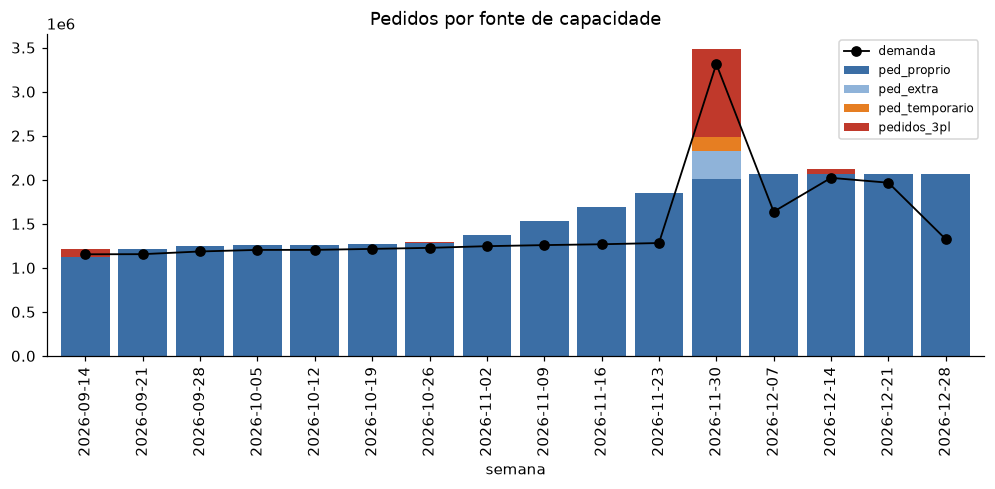

In [10]:
ax = r.plano[['ped_proprio','ped_extra','ped_temporario','pedidos_3pl']].plot.bar(stacked=True, figsize=(11, 3.8), width=0.85,
      color=['#3b6ea5','#8fb3d9','#e67e22','#c0392b'], title='Pedidos por fonte de capacidade')
ax.plot(range(len(r.plano)), r.plano.demanda, color='black', marker='o', lw=1.2, label='demanda'); ax.legend(fontsize=8)
r.custo_marginal_pedido.round(2).to_frame().T

**Leituras para o comitê executivo**

- **O gargalo do pico é o recrutamento, não o orçamento.** Com teto de contratações por semana, o modelo começa a contratar **5 semanas antes** da Black Friday. Isso conecta o KPI de RH (*time-to-fill*, turnover precoce) diretamente ao OTD de dezembro.
- **Preço-sombra.** Na semana da Black Friday, **um pedido a mais custa ~6× o custo médio**. Esse número precisa estar na mesa quando o marketing propõe "mais uma campanha" para aquela semana.
- **Qualidade tem preço, e ele é não linear.** Veja a curva abaixo.

In [11]:
curva = capacidade.curva_tradeoff(cen, 'acuracia_meta', [0.995, 0.996, 0.9964, 0.9966, 0.9968, 0.997])
curva['custo_incremental_mi'] = (curva.custo_total - curva.custo_total.min()) / 1e6
curva[['acuracia_meta','custo_total','custo_incremental_mi','participacao_3pl']]

,acuracia_meta,custo_total,custo_incremental_mi,participacao_3pl
0,0.9950,"152,056,835.9729",0.0000,0.0674
1,0.9960,"152,056,835.9729",0.0000,0.0674
2,0.9964,"152,056,835.9729",0.0000,0.0674
3,0.9966,"154,340,634.1881",2.2838,0.0611
4,0.9968,"161,516,864.2751",9.4600,0.0424
5,0.9970,"177,097,224.7318",25.0404,0.0320


Até ~99,64% a meta de acurácia **não custa nada** (a restrição está folgada). A partir daí, cada centésimo de ponto percentual custa milhões, porque força trocar temporário e 3PL por quadro próprio. A decisão certa depende do **custo de um erro** (logística reversa, reenvio, SAC, recompra perdida). Esse número vem de um projeto DMAIC, não de achismo.

In [12]:
pd.concat([capacidade.curva_tradeoff(cen, 'limite_3pl', [0, .1, .2, .3, .4]).set_index('limite_3pl')[['custo_total','participacao_3pl']],
          ], axis=1)

,custo_total,participacao_3pl
limite_3pl,,
0.0000,"185,636,282.6430",0.0000
0.1000,"176,432,348.2041",0.0148
0.2000,"168,522,050.6855",0.0276
0.3000,"161,516,864.2751",0.0424
0.4000,"157,221,429.6209",0.0624


**Dependência de 3PL (KRI).** Proibir 3PL encarece o pico em ~R$ 24 mi; liberar até 40% economiza pouco. Um teto de 20–30% preserva flexibilidade sem transferir o risco operacional do pico para o parceiro. Na operação híbrida, é um *trade-off* de governança, não só de custo.

## 6. OKRs 2026 · nota calculada dos dados (3T26 vs. 2S25)

In [13]:
krs, objs = okr.pontuar(d)
krs[['kr','descricao','tipo','linha_base','meta','atual','nota','status']]

,kr,descricao,tipo,linha_base,meta,atual,nota,status
0,KR1.1,OTD vs. promessa,committed,0.8949,0.9600,0.9353,0.6209,em risco
1,KR1.2,Entrega na 1ª tentativa (FADR),committed,0.9026,0.9300,0.9386,1.0000,atingido
2,KR1.3,Contatos no SAC por 100 pedidos,aspirational,4.8798,1.5000,3.0653,0.5369,em risco
3,KR2.1,Pedidos entregues em até 48h (Brasil),aspirational,0.6501,0.8000,0.7298,0.5319,em risco
4,KR2.2,Entregues em até 48h no Nordeste,committed,0.4874,0.6500,0.6638,1.0000,atingido
5,KR2.3,On-time departure do line-haul,committed,0.9574,0.9900,0.9932,1.0000,atingido
6,KR3.1,"Acurácia de picking (WERC best-in-class 99,68%)",committed,0.9964,0.9968,0.9973,1.0000,atingido
7,KR3.2,"Dock-to-stock P90 (WERC < 3,5 h)",aspirational,7.3433,4.0000,4.9580,0.7135,atingido
8,KR3.3,Expedição no cut-off,committed,0.9620,0.9900,0.9821,0.7166,em risco
9,KR4.1,POAS (lucro bruto atribuído / mídia),committed,1.5379,1.8000,1.8966,1.0000,atingido


In [14]:
objs[['objetivo','pilar','nota_media','contrapeso','contrapeso_ok']]

,objetivo,pilar,nota_media,contrapeso,contrapeso_ok
0,O1,Referência em confiabilidade para o cliente,0.7193,Tentativa falsa ≤ 1%,True
1,O2,Expandir a operação para nível nacional,0.8440,"Custo por kg transferido ≤ R$ 3,30",False
2,O3,Atualizar a operação com tecnologia de mercado,0.8100,Produtividade ≥ 12 linhas/HH,True
3,O4,Aumentar receita com crescimento rentável,0.8769,Taxa de frequência de acidentes ≤ 12,True


In [15]:
kpis.calcular(d, 'MM-004', freq='QS', por='regiao_id').unstack().round(2)

regiao_id,CO,N,NE,S,SE
data,,,,,
2025-01-01,NaN,NaN,NaN,2.5600,1.0700
2025-04-01,6.4600,NaN,6.7700,2.5400,1.0700
2025-07-01,6.0300,17.9900,6.6300,2.5600,1.0600
2025-10-01,5.8700,16.9700,6.5700,2.5100,1.0600
2026-01-01,5.8400,16.8200,6.5700,2.5300,1.0700
2026-04-01,5.8200,16.8200,6.6000,2.5200,1.0700
2026-07-01,5.8000,16.6500,6.5900,2.5200,1.0600


**Leitura de governança.** O O2 (expansão nacional) tem nota alta, mas **violou o contrapeso de custo por kg transferido**. A causa é **efeito mix**, como mostra a quebra por região acima: o Norte custa ~16× o Sudeste por kg, e cada ponto de participação do N/NE sobe a média nacional. Um contrapeso não estratificado penaliza a própria estratégia de expansão. A correção de governança é medir o contrapeso **por região** (ou com mix constante) e decidir no S&OP qual custo é o preço aceito da promessa nacional.

---
*Material de portfólio. Empresa e dados fictícios; referências de mercado citadas com fonte pública.*